In [3]:
from model.wrapper import NewMDGenWrapper
from model.tensor_utils import get_offsets, get_absolute
from model.rigid_utils import Rigid, quat_multiply, rot_vec_mul, quat_to_rot
import matplotlib.pyplot as plt
import numpy as np
import torch


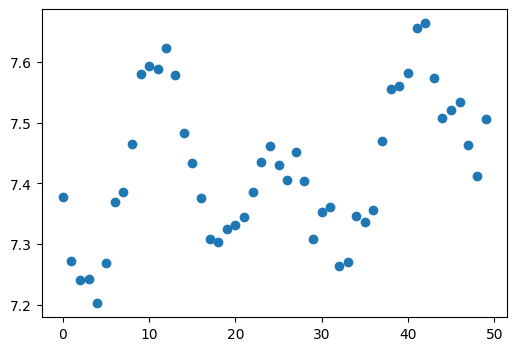

In [7]:
ori_traj = np.load('C:\\Users\\Kevin2\\ML_project\\PMMA_mdgen\\model\\data\\pmma_trajectory_1w.npy')

trans = ori_traj[5000:5050, :, 4:7]  # Shape: [50, 60, 3] T,N,3
rots = ori_traj[5000:5050, :, :4]  # Shape: [50, 60, 4] T,N,4
# convert to torch
trans = torch.from_numpy(trans).float()
rots = torch.from_numpy(rots).float()
T = torch.arange(trans.shape[0])[:, None]  # Shape: [T, 1]

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(T, trans[:, 0, 0])
# xy equal
# ax.set_aspect('equal', adjustable='box')
# the trajectory is continuous and smooth, which is expected for a molecular dynamics simulation. The x-coordinate

In [8]:
trajectory = torch.cat([rots.unsqueeze(0), trans.unsqueeze(0)], dim=-1)
rigids = Rigid.from_tensor_7(trajectory, normalize_quats=True)

$$g_0^{-1} = (R_0^{-1}, -R_0^{-1}\vec{t}_0)$$
$$g_0^{-1} g_t = (R_0^{-1}R_t, R_0^{-1}(\vec{t}_t - \vec{t}_0))$$

In [9]:
def get_offsets(rots, trans):

    q0 = rots[:, 0:1, :, :] # Shape: (B, 1, N, 4) order qw, qx, qy, qz
    t0 = trans[:, 0:1, :, :] # Shape: (B, 1, N, 3) order x, y, z
    
    # The inverse of a unit quaternion [w, x, y, z] is [w, -x, -y, -z]
    q0_inv = q0.clone()
    q0_inv[..., 1:] *= -1
    
    # Calculate relative quaternions: q_rel = q0_inv * q_t
    q_rel = quat_multiply(q0_inv, rots)
    
    # Calculate relative translations: t_rel = R0_inv * (t_t - t0)
    t_diff = trans - t0
    r0_inv_mat = quat_to_rot(q0_inv) # Convert inverse quat to 3x3 matrix once
    t_rel = rot_vec_mul(r0_inv_mat, t_diff)
    
    # Combine into relative offsets
    offsets = torch.cat([q_rel, t_rel], dim=-1)
    
    # Canonicalize quaternions (force positive real part for continuity)
    offsets[..., :4] *= torch.where(offsets[..., 0:1] < 0, -1, 1)
    return offsets

In [10]:
offsets = get_offsets(rots.unsqueeze(0), trans.unsqueeze(0))
q_rel = offsets[..., :4]
t_rel = offsets[..., 4:]
ref_rigids = rigids[:, 0]  # Reference frame is the first frame

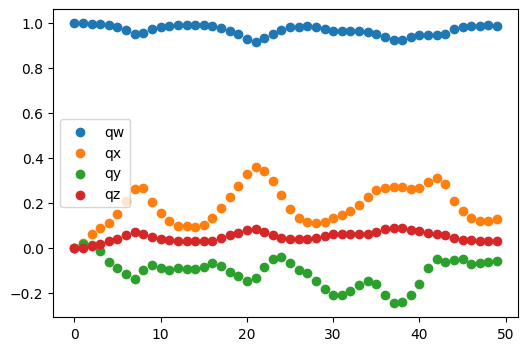

In [11]:
aid = 20
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(T, q_rel[0, :, aid, 0], label='qw')
ax.scatter(T, q_rel[0, :, aid, 1], label='qx')  
ax.scatter(T, q_rel[0, :, aid, 2], label='qy')
ax.scatter(T, q_rel[0, :, aid, 3], label='qz')
ax.legend()

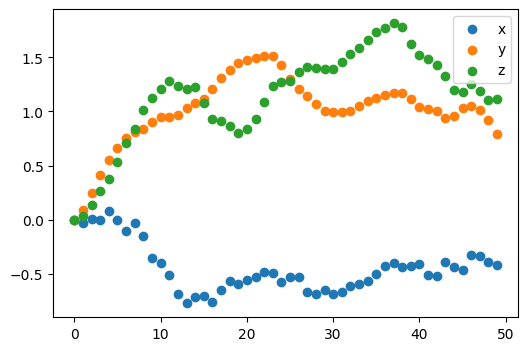

In [12]:
aid = 20
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(T, t_rel[0, :, aid, 0], label='x')
ax.scatter(T, t_rel[0, :, aid, 1], label='y')
ax.scatter(T, t_rel[0, :, aid, 2], label='z')
ax.legend()

In [13]:

absolute_trajectory = get_absolute(q_rel, t_rel, ref_rigids)

In [14]:
(absolute_trajectory - trajectory).abs().max()

tensor(1.9820)

## test inference

In [16]:
gen_traj = np.load("C:\\Users\\Kevin2\\ML_project\\PMMA_mdgen\\result\\1.2_50frames_PMMA_1w\\inference\\infe_traj.npy", allow_pickle=True)
rots_gen = gen_traj[:,:, :4]
trans_gen = gen_traj[:,:, 4:7]
offsets_gen = get_offsets(torch.tensor(rots_gen).unsqueeze(0), torch.tensor(trans_gen).unsqueeze(0))
q_rel_gen = offsets_gen[..., :4]
t_rel_gen = offsets_gen[..., 4:]

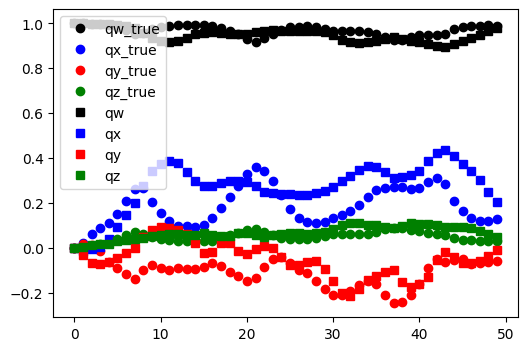

In [17]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(T, q_rel[0, :, aid, 0], 'ko', label='qw_true')
ax.plot(T, q_rel[0, :, aid, 1], 'bo', label='qx_true')
ax.plot(T, q_rel[0, :, aid, 2], 'ro', label='qy_true')
ax.plot(T, q_rel[0, :, aid, 3], 'go', label='qz_true')
ax.plot(T, q_rel_gen[0, :, aid, 0], 'ks',label='qw')
ax.plot(T, q_rel_gen[0, :, aid, 1], 'bs', label='qx')  
ax.plot(T, q_rel_gen[0, :, aid, 2], 'rs', label='qy')
ax.plot(T, q_rel_gen[0, :, aid, 3], 'gs', label='qz')

ax.legend()

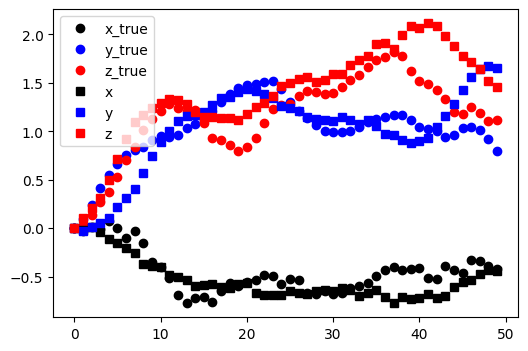

In [18]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(T, t_rel[0, :, aid, 0], 'ko', label='x_true')
ax.plot(T, t_rel[0, :, aid, 1], 'bo', label='y_true')
ax.plot(T, t_rel[0, :, aid, 2], 'ro', label='z_true')
ax.plot(T, t_rel_gen[0, :, aid, 0], 'ks',label='x')
ax.plot(T, t_rel_gen[0, :, aid, 1], 'bs', label='y')
ax.plot(T, t_rel_gen[0, :, aid, 2], 'rs', label='z')
ax.legend()

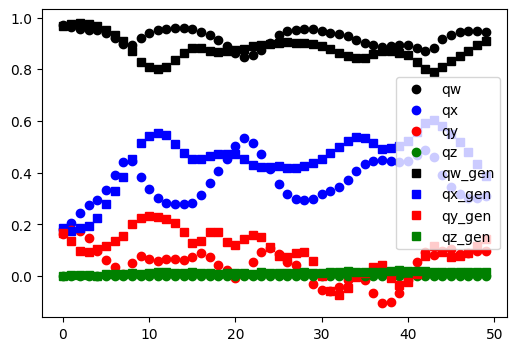

In [20]:
aid = 20
vid = 0

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(T, trajectory[0, :, aid, 0], 'ko', label='qw')
ax.plot(T, trajectory[0, :, aid, 1], 'bo', label='qx')
ax.plot(T, trajectory[0, :, aid, 2], 'ro', label='qy')
ax.plot(T, trajectory[0, :, aid, 3], 'go', label='qz')
ax.plot(T, gen_traj[:, aid, 0], 'ks', label='qw_gen') 
ax.plot(T, gen_traj[:, aid, 1], 'bs', label='qx_gen')
ax.plot(T, gen_traj[:, aid, 2], 'rs', label='qy_gen')
ax.plot(T, gen_traj[:, aid, 3], 'gs', label='qz_gen')
ax.legend()

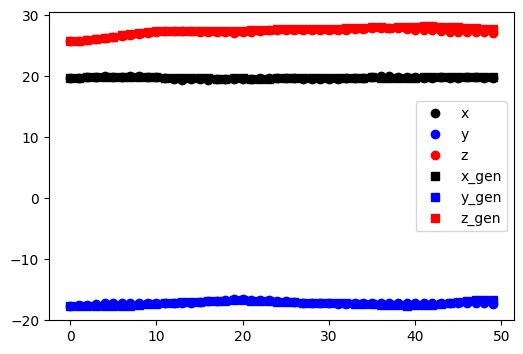

In [21]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(T, trajectory[0, :, aid, 4], 'ko', label='x')
ax.plot(T, trajectory[0, :, aid, 5], 'bo', label='y')
ax.plot(T, trajectory[0, :, aid, 6], 'ro', label='z')
ax.plot(T, gen_traj[:, aid, 4], 'ks', label='x_gen')
ax.plot(T, gen_traj[:, aid, 5], 'bs', label='y_gen')
ax.plot(T, gen_traj[:, aid, 6], 'rs', label='z_gen')
ax.legend()

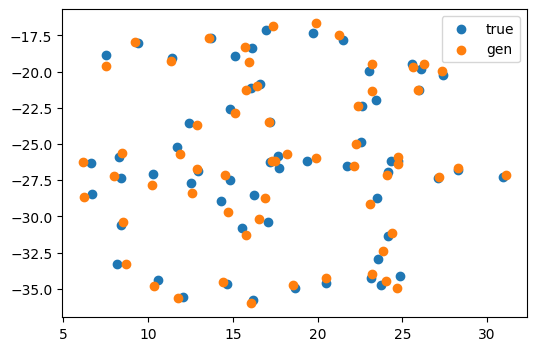

In [23]:
tid = 49
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(trans[tid, :, 0], trans[tid, :, 1], label='true')
ax.scatter(trans_gen [tid, :, 0], trans_gen[tid, :, 1], label='gen')
ax.legend()